In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\soulx\Downloads\geospatial_data.csv")

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns)

   RegionID       City        State  Latitude  Longitude PopulationSegment  \
0  REG-0001      Delhi        Delhi  28.65506   77.14308           Student   
1  REG-0002  Hyderabad    Telangana  17.45908   78.36344           Student   
2  REG-0003      Delhi        Delhi  28.56055   77.13678      Professional   
3  REG-0004    Kolkata  West Bengal  22.70194   88.38826      Professional   
4  REG-0005       Pune  Maharashtra  18.58053   73.76657           Student   

   MonthlySearchDemand  ExistingCompetitors  MedianAnnualIncomeINR  \
0                 1071                    9                 812870   
1                  654                   15                 938393   
2                  574                   10                 445873   
3                  389                    4                 802466   
4                  538                   11                 370930   

   LeadConversionRate  EstimatedAcquisitionCostINR  
0              0.1116                          618  
1   

In [7]:
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSummary Statistics:")
display(df.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RegionID                     400 non-null    str    
 1   City                         400 non-null    str    
 2   State                        400 non-null    str    
 3   Latitude                     400 non-null    float64
 4   Longitude                    400 non-null    float64
 5   PopulationSegment            400 non-null    str    
 6   MonthlySearchDemand          400 non-null    int64  
 7   ExistingCompetitors          400 non-null    int64  
 8   MedianAnnualIncomeINR        400 non-null    int64  
 9   LeadConversionRate           400 non-null    float64
 10  EstimatedAcquisitionCostINR  400 non-null    int64  
dtypes: float64(3), int64(4), str(4)
memory usage: 47.6 KB

Missing Values:
RegionID                       0
City                         

,Latitude,Longitude,MonthlySearchDemand,ExistingCompetitors,MedianAnnualIncomeINR,LeadConversionRate,EstimatedAcquisitionCostINR
count,400.000000,400.000000,400.000000,400.000000,4.000000e+02,400.000000,400.0000
mean,19.514412,77.189472,1061.547500,7.770000,6.743837e+05,0.079196,461.5500
std,6.024531,4.090443,506.055048,4.430143,2.259640e+05,0.036676,217.9737
min,9.755410,72.397790,189.000000,1.000000,2.850710e+05,0.018200,91.0000
25%,13.136885,73.839768,630.500000,4.000000,4.727375e+05,0.047100,268.0000
50%,18.668290,77.082815,1055.000000,8.000000,6.912940e+05,0.079700,451.0000
75%,23.141262,78.489573,1484.000000,12.000000,8.781878e+05,0.111625,645.7500
max,28.767430,88.534650,1899.000000,15.000000,1.047851e+06,0.139700,850.0000


In [8]:
print("Unique States:", df["State"].nunique())
print("Unique Cities:", df["City"].nunique())

print("\nStates:")
print(df["State"].unique())

print("\nPopulation Segments:")
print(df["PopulationSegment"].value_counts())

Unique States: 9
Unique Cities: 10

States:
<ArrowStringArray>
[      'Delhi',   'Telangana', 'West Bengal', 'Maharashtra',   'Rajasthan',
     'Gujarat',  'Tamil Nadu',   'Karnataka',      'Kerala']
Length: 9, dtype: str

Population Segments:
PopulationSegment
Professional    145
Student         138
Early Career    117
Name: count, dtype: int64


In [9]:
df["RevenuePotentialINR"] = (
    df["MonthlySearchDemand"] *
    df["LeadConversionRate"] *
    df["MedianAnnualIncomeINR"]
)

df["DemandPerCompetitor"] = (
    df["MonthlySearchDemand"] /
    (df["ExistingCompetitors"] + 1)
)

df["DemandPer1000People"] = (
    df["MonthlySearchDemand"] /
    1000
)

print("===== REGIONAL METRICS =====")
display(
    df[
        [
            "City",
            "State",
            "MonthlySearchDemand",
            "ExistingCompetitors",
            "LeadConversionRate",
            "RevenuePotentialINR",
            "DemandPerCompetitor"
        ]
    ].head(10)
)

===== REGIONAL METRICS =====


,City,State,MonthlySearchDemand,ExistingCompetitors,LeadConversionRate,RevenuePotentialINR,DemandPerCompetitor
0,Delhi,Delhi,1071,9,0.1116,9.715715e+07,107.100000
1,Hyderabad,Telangana,654,15,0.1228,7.536347e+07,40.875000
2,Delhi,Delhi,574,10,0.1191,3.048139e+07,52.181818
3,Kolkata,West Bengal,389,4,0.0308,9.614506e+06,77.800000
4,Pune,Maharashtra,538,11,0.0974,1.943718e+07,44.833333
5,Delhi,Delhi,658,1,0.0926,5.026389e+07,329.000000
6,Delhi,Delhi,938,15,0.1369,9.425366e+07,58.625000
7,Jaipur,Rajasthan,1529,11,0.0401,3.143261e+07,127.416667
8,Ahmedabad,Gujarat,645,14,0.1113,3.760368e+07,43.000000
9,Delhi,Delhi,568,13,0.0736,3.786123e+07,40.571429


In [10]:
state_analysis = df.groupby("State").agg(
    Cities=("City", "count"),
    TotalDemand=("MonthlySearchDemand", "sum"),
    TotalCompetitors=("ExistingCompetitors", "sum"),
    AverageConversion=("LeadConversionRate", "mean"),
    AverageAcquisitionCost=("EstimatedAcquisitionCostINR", "mean")
)

state_analysis["DemandPerCompetitor"] = (
    state_analysis["TotalDemand"] /
    (state_analysis["TotalCompetitors"] + 1)
)

state_analysis = state_analysis.sort_values(
    "TotalDemand",
    ascending=False
)

print("===== STATE ANALYSIS =====")
display(state_analysis)

===== STATE ANALYSIS =====


,Cities,TotalDemand,TotalCompetitors,AverageConversion,AverageAcquisitionCost,DemandPerCompetitor
State,,,,,,
Maharashtra,69,75849,526,0.077739,469.971014,143.925996
Tamil Nadu,47,53771,373,0.078796,411.680851,143.772727
Delhi,56,53007,449,0.072682,486.232143,117.793333
Gujarat,50,52110,419,0.084026,487.000000,124.071429
Telangana,42,48103,302,0.081524,438.571429,158.755776
Kerala,39,39015,265,0.080728,520.384615,146.672932
Rajasthan,33,34849,253,0.079764,446.848485,137.200787
West Bengal,32,34126,274,0.072641,392.500000,124.094545
Karnataka,32,33789,247,0.087828,476.343750,136.245968


In [11]:
df["OpportunityScore"] = (
    df["MonthlySearchDemand"] *
    df["LeadConversionRate"]
    / (df["ExistingCompetitors"] + 1)
)

opportunities = df.sort_values(
    "OpportunityScore",
    ascending=False
)

print("===== TOP 10 HIGH-POTENTIAL REGIONS =====")

display(
    opportunities[
        [
            "City",
            "State",
            "MonthlySearchDemand",
            "ExistingCompetitors",
            "LeadConversionRate",
            "EstimatedAcquisitionCostINR",
            "OpportunityScore"
        ]
    ].head(10)
)

===== TOP 10 HIGH-POTENTIAL REGIONS =====


,City,State,MonthlySearchDemand,ExistingCompetitors,LeadConversionRate,EstimatedAcquisitionCostINR,OpportunityScore
26,Kochi,Kerala,1816,1,0.1381,613,125.394800
352,Kolkata,West Bengal,1799,1,0.1355,727,121.882250
205,Kochi,Kerala,1787,1,0.1305,407,116.601750
383,Kochi,Kerala,1631,1,0.1199,507,97.778450
360,Pune,Maharashtra,1856,1,0.1052,645,97.625600
49,Bengaluru,Karnataka,1286,1,0.1352,600,86.933600
396,Hyderabad,Telangana,1580,1,0.1007,391,79.553000
236,Pune,Maharashtra,1459,2,0.1397,713,67.940767
322,Delhi,Delhi,1730,2,0.1136,734,65.509333
196,Ahmedabad,Gujarat,1338,1,0.0934,658,62.484600


In [12]:
top_3 = opportunities.head(3)

print("===== TOP 3 POTENTIAL UNDERSERVED REGIONS =====")

display(
    top_3[
        [
            "City",
            "State",
            "MonthlySearchDemand",
            "ExistingCompetitors",
            "LeadConversionRate",
            "EstimatedAcquisitionCostINR",
            "OpportunityScore"
        ]
    ]
)

===== TOP 3 POTENTIAL UNDERSERVED REGIONS =====


,City,State,MonthlySearchDemand,ExistingCompetitors,LeadConversionRate,EstimatedAcquisitionCostINR,OpportunityScore
26,Kochi,Kerala,1816,1,0.1381,613,125.39480
352,Kolkata,West Bengal,1799,1,0.1355,727,121.88225
205,Kochi,Kerala,1787,1,0.1305,407,116.60175


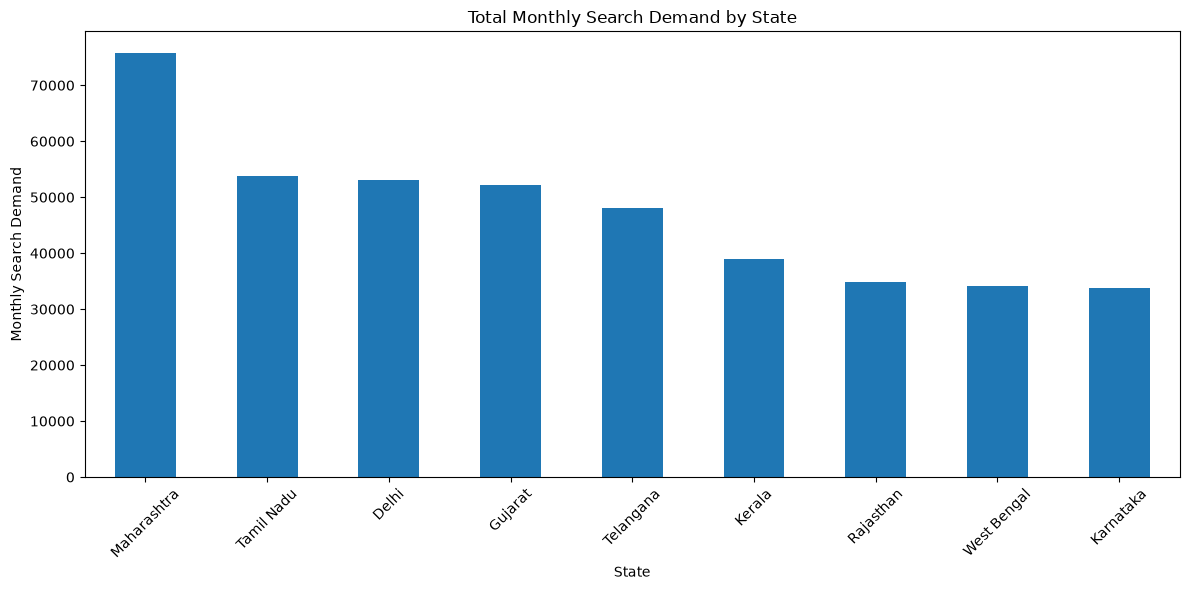

In [13]:
plt.figure(figsize=(12, 6))

state_demand = (
    df.groupby("State")["MonthlySearchDemand"]
    .sum()
    .sort_values(ascending=False)
)

state_demand.plot(kind="bar")

plt.title("Total Monthly Search Demand by State")
plt.xlabel("State")
plt.ylabel("Monthly Search Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

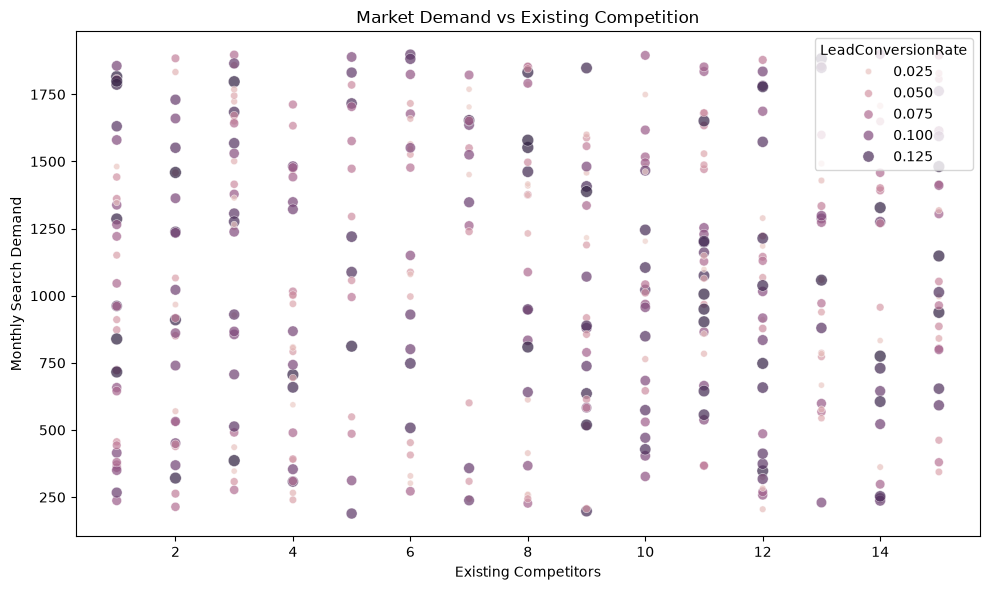

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="ExistingCompetitors",
    y="MonthlySearchDemand",
    size="LeadConversionRate",
    hue="LeadConversionRate",
    alpha=0.7
)

plt.title("Market Demand vs Existing Competition")
plt.xlabel("Existing Competitors")
plt.ylabel("Monthly Search Demand")
plt.tight_layout()
plt.show()

In [15]:
import folium

center_lat = df["Latitude"].mean()
center_lon = df["Longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5
)

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=5,
        popup=(
            f"<b>{row['City']}, {row['State']}</b><br>"
            f"Search Demand: {row['MonthlySearchDemand']}<br>"
            f"Competitors: {row['ExistingCompetitors']}<br>"
            f"Conversion Rate: {row['LeadConversionRate']:.2f}<br>"
            f"Opportunity Score: {row['OpportunityScore']:.2f}"
        ),
        fill=True
    ).add_to(m)

m

In [16]:
m.save("geospatial_analysis_map.html")

print("Map saved successfully as geospatial_analysis_map.html")

Map saved successfully as geospatial_analysis_map.html


In [17]:
top_3 = opportunities.head(3)

m_top = folium.Map(
    location=[df["Latitude"].mean(), df["Longitude"].mean()],
    zoom_start=5
)

for _, row in df.iterrows():
    is_top = row["RegionID"] in top_3["RegionID"].values

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=9 if is_top else 4,
        popup=(
            f"<b>{row['City']}, {row['State']}</b><br>"
            f"Demand: {row['MonthlySearchDemand']}<br>"
            f"Competitors: {row['ExistingCompetitors']}<br>"
            f"Conversion: {row['LeadConversionRate']:.2f}<br>"
            f"Opportunity Score: {row['OpportunityScore']:.2f}"
        ),
        fill=True
    ).add_to(m_top)

m_top

In [18]:
m_top.save("geospatial_opportunity_map.html")

print("Final map saved as geospatial_opportunity_map.html")

Final map saved as geospatial_opportunity_map.html


In [19]:
final_regions = top_3[
    [
        "City",
        "State",
        "Latitude",
        "Longitude",
        "MonthlySearchDemand",
        "ExistingCompetitors",
        "LeadConversionRate",
        "EstimatedAcquisitionCostINR",
        "OpportunityScore"
    ]
].copy()

final_regions = final_regions.reset_index(drop=True)
final_regions.index = final_regions.index + 1

display(final_regions)

,City,State,Latitude,Longitude,MonthlySearchDemand,ExistingCompetitors,LeadConversionRate,EstimatedAcquisitionCostINR,OpportunityScore
1,Kochi,Kerala,9.89077,76.21609,1816,1,0.1381,613,125.39480
2,Kolkata,West Bengal,22.56327,88.43367,1799,1,0.1355,727,121.88225
3,Kochi,Kerala,9.97188,76.35779,1787,1,0.1305,407,116.60175


In [20]:
print("===== GEOSPATIAL ANALYSIS SUMMARY =====")
print("Total Regions:", len(df))
print("Total States:", df["State"].nunique())
print("Total Cities:", df["City"].nunique())
print("Total Monthly Search Demand:", df["MonthlySearchDemand"].sum())
print("Total Existing Competitors:", df["ExistingCompetitors"].sum())
print("Average Lead Conversion Rate:", round(df["LeadConversionRate"].mean(), 4))
print(
    "Average Acquisition Cost (INR):",
    round(df["EstimatedAcquisitionCostINR"].mean(), 2)
)

===== GEOSPATIAL ANALYSIS SUMMARY =====
Total Regions: 400
Total States: 9
Total Cities: 10
Total Monthly Search Demand: 424619
Total Existing Competitors: 3108
Average Lead Conversion Rate: 0.0792
Average Acquisition Cost (INR): 461.55


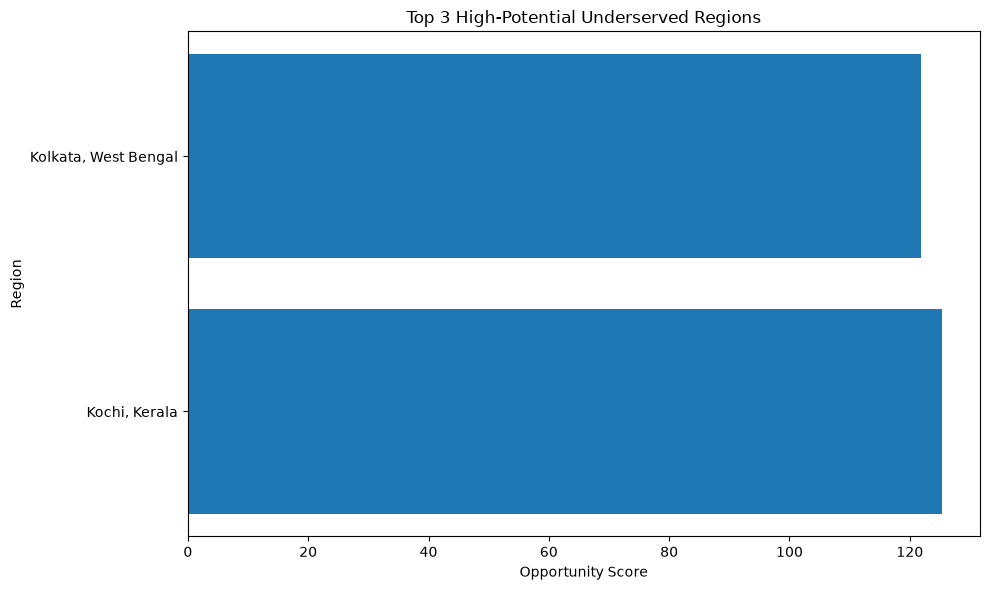

In [21]:
plt.figure(figsize=(10, 6))

plot_data = top_3.sort_values("OpportunityScore", ascending=True)

plt.barh(
    plot_data["City"] + ", " + plot_data["State"],
    plot_data["OpportunityScore"]
)

plt.title("Top 3 High-Potential Underserved Regions")
plt.xlabel("Opportunity Score")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

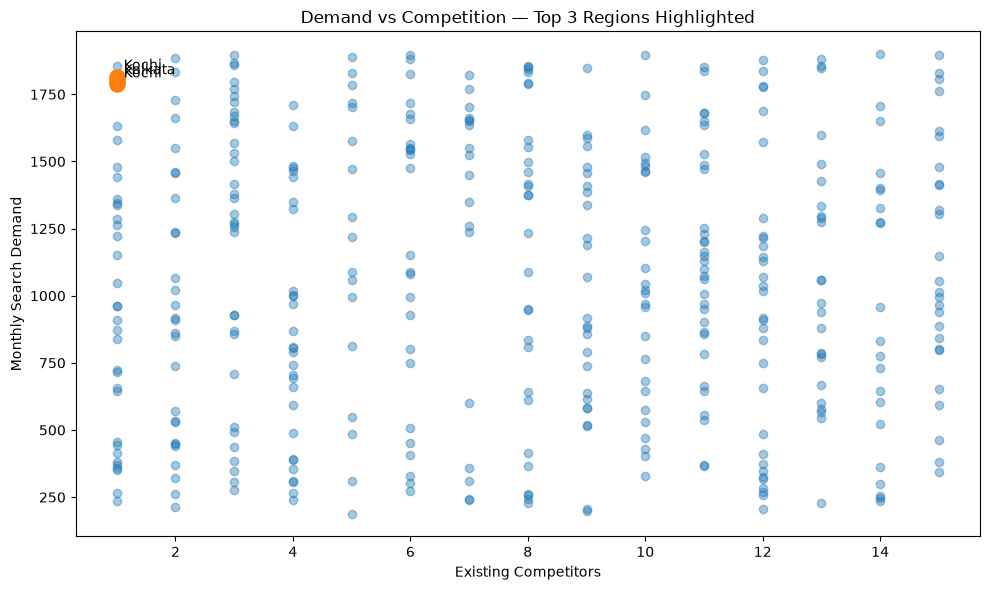

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["ExistingCompetitors"],
    df["MonthlySearchDemand"],
    alpha=0.4
)

plt.scatter(
    top_3["ExistingCompetitors"],
    top_3["MonthlySearchDemand"],
    s=120
)

for _, row in top_3.iterrows():
    plt.annotate(
        row["City"],
        (row["ExistingCompetitors"], row["MonthlySearchDemand"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Demand vs Competition — Top 3 Regions Highlighted")
plt.xlabel("Existing Competitors")
plt.ylabel("Monthly Search Demand")
plt.tight_layout()
plt.show()

## Conclusion

The geospatial analysis examined regional search demand, existing competition, lead conversion rates, and acquisition costs across the dataset.

The analysis identified three regions with relatively strong opportunity scores based on a combination of market demand, conversion potential, and competition levels.

Key findings:
- Search demand varies considerably across regions.
- Regions with high demand and comparatively fewer competitors represent potential underserved markets.
- Lead conversion rate provides an additional indicator of market potential.
- Geographic visualization helps identify spatial patterns that are difficult to observe from tables alone.

The Opportunity Score is a constructed prioritization metric and should be treated as an analytical indicator rather than a direct estimate of revenue or profit.

The interactive map provides a geographic view of regional opportunities and can support further market-expansion analysis.